In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import butter, filtfilt


# Normalizei os dados
dados = np.load('Fz.npy')

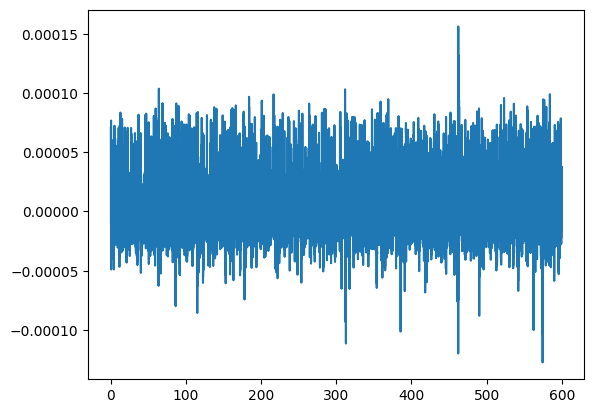

In [3]:
t = np.linspace(0,307200/512, 307200)
plt.plot(t,dados[0,:])

#Aqui fica claro que:
- Foi aplicado um passa baixas com corte em 128 hz
- Há uma frequência de rede em 50 Hz
- O sinal tem um nível DC altíssimo






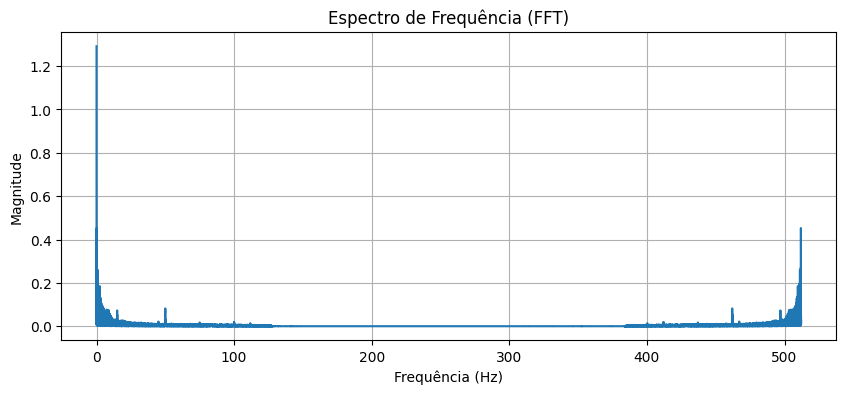

In [4]:
f = np.linspace(0,512,307200)
fs = 512
fft_valores= np.fft.fft(dados[0,:])
magnitude = np.abs(fft_valores)

# Visualização
plt.figure(figsize=(10, 4))
plt.plot(f, magnitude)
plt.title("Espectro de Frequência (FFT)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

#Focando no trecho que importa para gente

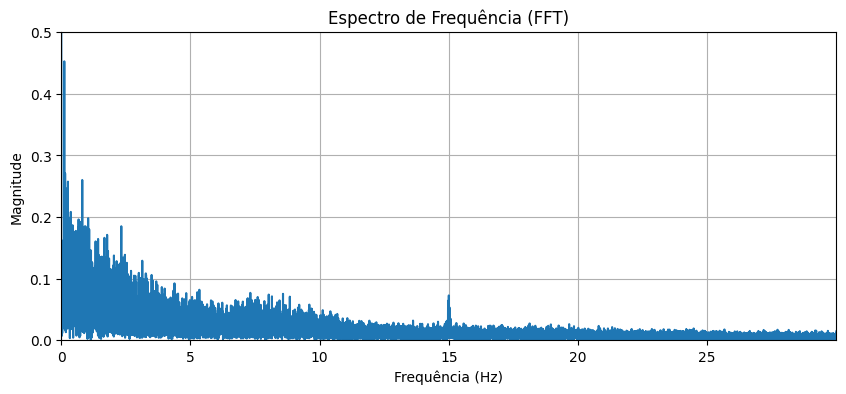

In [5]:
# Visualização
plt.figure(figsize=(10, 4))
plt.plot(f, magnitude)
plt.title("Espectro de Frequência (FFT)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0,30)
plt.ylim(0,0.5)
plt.xticks(np.arange(0, 30, 5))
plt.grid()
plt.show()

# No canal Fz tem mto artefato muscular de piscada e movimentação do olho, então vou focar de 3 Hz a 30 Hz, aplicando um filtro Passa-Banda (Butterworth).

- Em outros canais podemos aproveitar melhor as frequências<3Hz
- Filtrando acima de 3Hz vamos perder um pouco as piscadas

In [6]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, data)

# Aplicando o filtro no sinal bruto
sinal_filtrado = butter_bandpass_filter(dados[0,:],3, 30.0, fs, order=4)

#CWT no sinal filtrado
- Precisamos testar a resolução da wavelet, fixei em 3 aqui o cmor, mas preciso entender melhor isto
- calculei em escala log

(15360,)


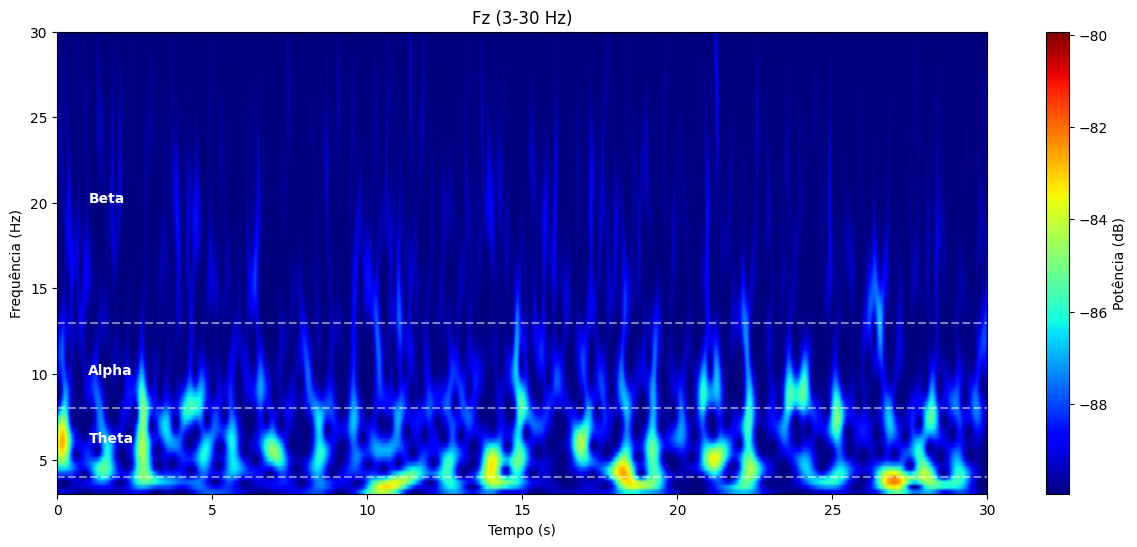

In [ ]:
wavelet = 'morl'
freqs = np.linspace(3, 30, 100)
scales = pywt.frequency2scale(wavelet, freqs * (1/fs))

janela = sinal_filtrado[0:30*512]


coef, _ = pywt.cwt(janela, scales, wavelet, sampling_period=1/fs)
potencia = np.abs(coef)**2
potencia_db = 10 * np.log10(potencia + 1e-9)  # Para garantir que não teremos log(0)


# Ajustando o contraste no gráfico
vmin = np.percentile(potencia_db, 25)
#vmax = np.percentile(potencia_db, 98)
vmax = vmin+10

plt.figure(figsize=(15, 6))
plt.imshow(potencia_db,
           extent=[0, 30, 3, 30],
           cmap='jet',
           aspect='auto',
           origin='lower',
           vmin=vmin, vmax=vmax)

plt.title("Fz (3-30 Hz)")
plt.ylabel("Frequência (Hz)")
plt.xlabel("Tempo (s)")

# Marcadores visuais
plt.axhline(4, color='white', linestyle='--', alpha=0.5)
plt.axhline(8, color='white', linestyle='--', alpha=0.5)
plt.axhline(13, color='white', linestyle='--', alpha=0.5)
plt.text(1, 6, 'Theta', color='white', fontweight='bold')
plt.text(1, 10, 'Alpha', color='white', fontweight='bold')
plt.text(1, 20, 'Beta', color='white', fontweight='bold')

plt.colorbar(label="Potência (dB)")
plt.show()

###Beta (> 13 Hz) - tudo azul

O córtex pré-frontal (Fz) está "desligado" para tarefas cognitivas. Se o sujeito estivesse alerta, processando informações ou focado, veríamos "fagulhas" ciano ou verdes aqui. O azul total confirma baixa vigilância.

###Theta (4 - 8 Hz)
Manchas amarelas/verdes brilhantes que aparecem ritmicamente (por exemplo, aos 2s, 6s, 14s, 18s, 22s, 27s) - são Explosões de Theta (Theta Bursts).

No Fz, isso é o marcador biológico da pressão do sono. O cérebro não está conseguindo manter a atividade rápida e "escorrega" para frequências lentas a cada poucos segundos.

Note que não é uma linha contínua. É cíclico. O sujeito luta para ficar acordado, o Theta sobe, ele reage (talvez pisque), e o ciclo repete.

### Alpha/Theta (8 - 10 Hz)
As manchas amarelas não ficam presas só no Theta; elas invadem a parte de baixo do Alpha. Isso é clássico do estágio de transição Vigília-Sono (N1). O Alpha (relaxamento) começa a desacelerar e se fundir com o Theta.

###(< 4 Hz)
Aqui temos o transitório do filtro, mas as manchas vermelhas/laranjas bem na base indicam resíduo de movimento ocular (piscadas lentas). O fato de essas manchas na base coincidirem com as "Ilhas de Theta" acima confirma que as piscadas estão sincronizadas com as ondas de sonolência. O sujeito sente o sono vir (Theta), os olhos pesam (piscada lenta), e o gráfico acende.